In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load the Bars from path
paths = {
  "Tick": Path("../data/es_tick_bars.csv"),
  "Volume": Path("../data/es_volume_bars.csv"),
  "Dollar": Path("../data/es_dollar_bars.csv")
}

# Notify if files are missing
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {', '.join(missing)}")


# read the CSV files into DataFrames
tick_bars = pd.read_csv(paths["Tick"], parse_dates=["timestamp"])
volume_bars = pd.read_csv(paths["Volume"], parse_dates=["timestamp"])
dollar_bars = pd.read_csv(paths["Dollar"], parse_dates=["timestamp"])

# print the bars
print("Tick:", len(tick_bars))
print("Volume:", len(volume_bars))
print("Dollar:", len(dollar_bars))

Tick: 150
Volume: 149
Dollar: 149


In [3]:
# Calculate the log returns

def add_log_returns(bars):
    x = bars.copy()
    x["log_return"] = np.log(x["close"] / x["close"].shift(1))
    return x.dropna(subset=["log_return"])

tick_bars = add_log_returns(tick_bars)
volume_bars = add_log_returns(volume_bars)
dollar_bars = add_log_returns(dollar_bars)

display(tick_bars[["timestamp", "close", "log_return"]].head())
display(volume_bars[["timestamp", "close", "log_return"]].head())
display(dollar_bars[["timestamp", "close", "log_return"]].head())


,timestamp,close,log_return
1,2013-09-01 19:20:09.224,1641.50,0.000609
2,2013-09-01 20:44:29.770,1642.25,0.000457
3,2013-09-01 23:13:07.101,1643.00,0.000457
4,2013-09-02 01:29:18.999,1644.00,0.000608
5,2013-09-02 02:08:37.675,1643.50,-0.000304


,timestamp,close,log_return
1,2013-09-01 19:09:34.288,1640.75,0.000152
2,2013-09-01 20:22:03.553,1642.50,0.001066
3,2013-09-02 00:00:47.925,1643.00,0.000304
4,2013-09-02 02:00:48.477,1643.50,0.000304
5,2013-09-02 02:25:26.240,1645.00,0.000912


,timestamp,close,log_return
1,2013-09-01 19:09:34.288,1640.75,0.000152
2,2013-09-01 20:22:59.983,1642.50,0.001066
3,2013-09-02 00:00:47.925,1643.00,0.000304
4,2013-09-02 02:00:46.464,1643.50,0.000304
5,2013-09-02 02:25:26.240,1645.00,0.000912


In [12]:
# compute variance of returns for each month
def daily_return_variance(bars):
    x = bars.copy()
    x["day"] = x["timestamp"].dt.date
    return x.groupby("day")["log_return"].var()

daily_var = pd.DataFrame({
    "Tick": daily_return_variance(tick_bars),
    "Volume": daily_return_variance(volume_bars),
    "Dollar": daily_return_variance(dollar_bars)
})
display(daily_var)

,Tick,Volume,Dollar
day,,,
2013-09-01,7.771829e-09,4.173654e-07,4.173654e-07
2013-09-02,3.211975e-07,6.853900e-07,5.850662e-07
2013-09-03,4.074109e-07,4.149816e-07,4.441240e-07


In [13]:
# compute the variance of the monthly variance
variance_of_daily_var = daily_var.var()

result = pd.DataFrame({
  "Variance of Daily Variance": variance_of_daily_var
})

result = result.sort_values(by="Variance of Daily Variance")
display(result)

,Variance of Daily Variance
Dollar,8.117375e-15
Volume,2.416060e-14
Tick,4.422996e-14


In [14]:
# identify the most stable bar type
most_stable_bar_type = result.index[0]

print("Most stable variance structure:", most_stable_bar_type)
print("Variance of daily variance:", result.loc[most_stable_bar_type, "Variance of Daily Variance"])

Most stable variance structure: Dollar
Variance of daily variance: 8.117374659002733e-15


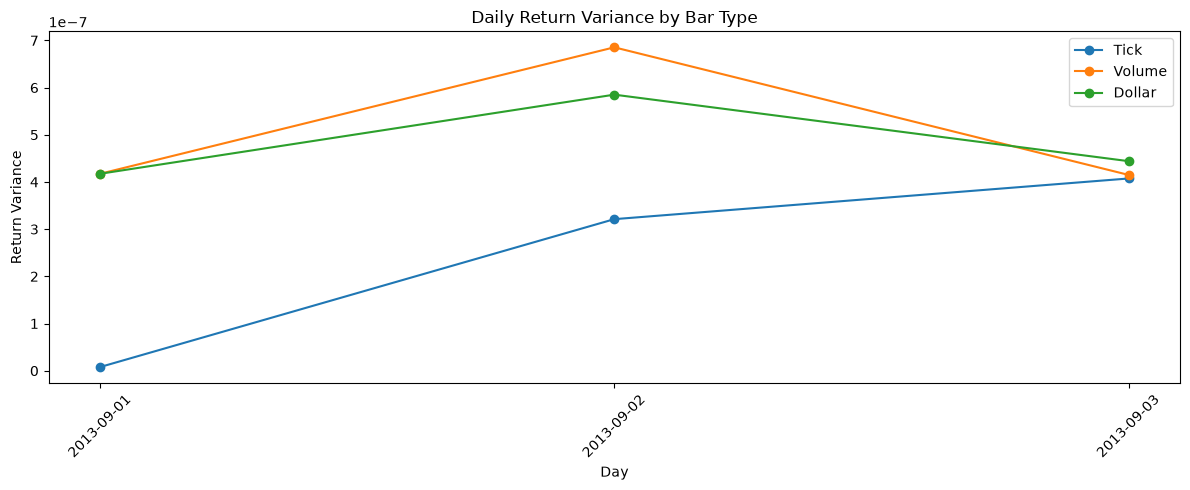

In [15]:
# Plot monthly return variance
plt.figure(figsize=(12, 5))

plt.plot(daily_var.index.astype(str), daily_var["Tick"], marker="o", label="Tick")
plt.plot(daily_var.index.astype(str), daily_var["Volume"], marker="o", label="Volume")
plt.plot(daily_var.index.astype(str), daily_var["Dollar"], marker="o", label="Dollar")

plt.title("Daily Return Variance by Bar Type")
plt.xlabel("Day")
plt.ylabel("Return Variance")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

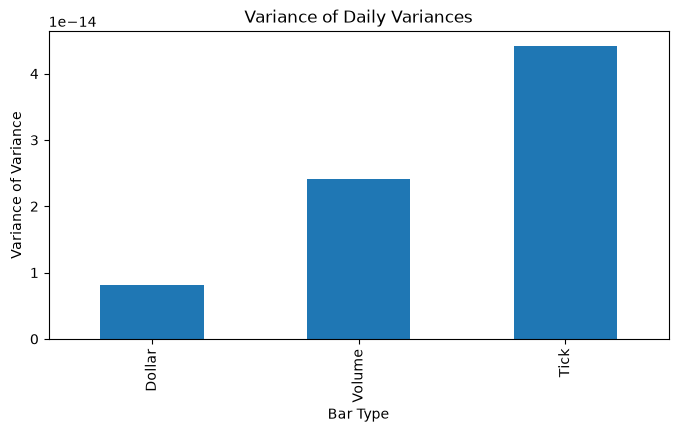

In [17]:
# Plot variance of variances
plt.figure(figsize=(8, 4))

result["Variance of Daily Variance"].sort_values().plot(kind="bar")

plt.title("Variance of Daily Variances")
plt.xlabel("Bar Type")
plt.ylabel("Variance of Variance")
plt.show()